# 3. Deep Learning Models — CNN & CRNN

ML baselines achieved ~50% accuracy with macro F1 of 0.27–0.32, struggling particularly on Wheeze and Both classes. This notebook trains deep learning models that learn directly from mel spectrograms:

1. **CNN (ResNet-style)** — treats spectrograms as images, captures spatial frequency patterns
2. **CRNN (CNN + BiGRU)** — extracts spatial features via CNN, then models temporal evolution via bidirectional GRU

Key advantages over handcrafted features:
- Learns task-specific representations rather than generic audio descriptors
- Preserves temporal structure within each respiratory cycle
- SpecAugment data augmentation for regularisation

In [1]:
# Setup
import sys
sys.path.append(r"E:\GitHub\lung-sound-classification")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.config import *
from src.models import LungSoundCNN, SpectrogramDataset
from src.evaluate import (
    train_cnn, predict_cnn, evaluate_predictions,
    plot_confusion_matrix, plot_training_curves, compare_models,
    get_device
)

device = get_device()
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 3.1 Load Pre-Extracted Spectrograms
Loading the mel spectrograms saved during Phase 2. Each spectrogram is a 2D array of shape (128 mel bins × time steps) representing the frequency content of a 5-second respiratory cycle.

In [2]:
data = np.load(DATA_DIR / 'mel_spectrograms.npz')
X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

print(f"Train: {X_train.shape}, labels: {np.bincount(y_train)}")
print(f"Val:   {X_val.shape}, labels: {np.bincount(y_val)}")
print(f"Test:  {X_test.shape}, labels: {np.bincount(y_test)}")

Train: (3809, 128, 216), labels: [2257  841  491  220]
Val:   (1386, 128, 216), labels: [585 506 171 124]
Test:  (1703, 128, 216), labels: [800 517 224 162]


## 3.2 Compute Class Weights
The dataset is imbalanced (Normal: 52.8%, Both: 7.3%). Rather than SMOTE (which is designed for tabular data), we use **inverse-frequency class weighting** in the loss function. This forces the model to pay proportionally more attention to minority classes during training.

In [3]:
# Compute inverse-frequency class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(class_weights)
print(f"Class weights: {class_weights}")
print(f"  Normal:  {class_weights[0]:.3f}")
print(f"  Crackle: {class_weights[1]:.3f}")
print(f"  Wheeze:  {class_weights[2]:.3f}")
print(f"  Both:    {class_weights[3]:.3f}")

# Create datasets (augmentation on train only)
train_dataset = SpectrogramDataset(X_train, y_train, augment=True)
val_dataset = SpectrogramDataset(X_val, y_val, augment=False)
test_dataset = SpectrogramDataset(X_test, y_test, augment=False)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verify shapes
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nBatch shape: {sample_batch.shape}")  # (batch, 1, 128, time_steps)
print(f"Labels shape: {sample_labels.shape}")

Class weights: tensor([0.4219, 1.1323, 1.9394, 4.3284])
  Normal:  0.422
  Crackle: 1.132
  Wheeze:  1.939
  Both:    4.328

Batch shape: torch.Size([32, 1, 128, 216])
Labels shape: torch.Size([32])


## 3.3 CNN Model (ResNet-Style)
A custom ResNet-inspired architecture with residual blocks for spectrogram classification:

Input (1, 128, T) → Conv7×7 + MaxPool
→ ResBlock(64) × 2 → ResBlock(128) × 2 → ResBlock(256) × 2
→ Global Average Pool → Dropout(0.5) → FC(4)

Residual (skip) connections allow gradients to flow directly through the network, enabling deeper architectures without degradation. SpecAugment applies random time/frequency masking during training for regularisation.

In [4]:
# Train CNN
cnn_model = LungSoundCNN(num_classes=4)
print(f"CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_history = train_cnn(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    class_weights=class_weights,
    model_name="cnn_resnet",
)

CNN parameters: 2,759,652
Training on: cuda
Epoch [  1/50] Train Loss: 1.4336  Acc: 0.3557  |  Val Loss: 1.4930  Acc: 0.2157
Epoch [  2/50] Train Loss: 1.3811  Acc: 0.3234  |  Val Loss: 1.4810  Acc: 0.3333
Epoch [  3/50] Train Loss: 1.3697  Acc: 0.3513  |  Val Loss: 1.4152  Acc: 0.2489
Epoch [  4/50] Train Loss: 1.3710  Acc: 0.3628  |  Val Loss: 1.4471  Acc: 0.0988
Epoch [  5/50] Train Loss: 1.3588  Acc: 0.3794  |  Val Loss: 1.3818  Acc: 0.3326
Epoch [  6/50] Train Loss: 1.3602  Acc: 0.3607  |  Val Loss: 1.4122  Acc: 0.2771
Epoch [  7/50] Train Loss: 1.3539  Acc: 0.3531  |  Val Loss: 1.4357  Acc: 0.3521
Epoch [  8/50] Train Loss: 1.3408  Acc: 0.3975  |  Val Loss: 1.4021  Acc: 0.3196
Epoch [  9/50] Train Loss: 1.3352  Acc: 0.3605  |  Val Loss: 1.4956  Acc: 0.3846
Epoch [ 10/50] Train Loss: 1.3062  Acc: 0.4182  |  Val Loss: 1.5158  Acc: 0.3608
Epoch [ 11/50] Train Loss: 1.2948  Acc: 0.3938  |  Val Loss: 1.4691  Acc: 0.2244
Epoch [ 12/50] Train Loss: 1.2910  Acc: 0.4022  |  Val Loss: 1.45

## 3.4 CNN Evaluation

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cnn_training_curves.png


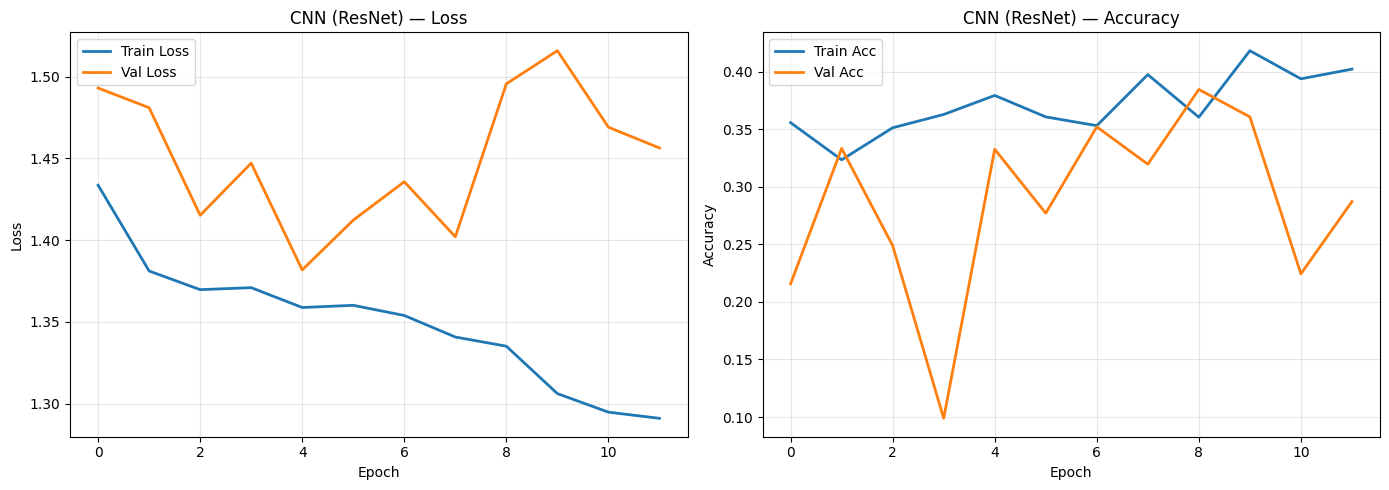


  CNN (ResNet)
  Accuracy:          0.4521
  F1 (macro):        0.2737
  F1 (weighted):     0.4074

              precision    recall  f1-score   support

      Normal       0.51      0.62      0.56       800
     Crackle       0.39      0.51      0.44       517
      Wheeze       0.33      0.00      0.01       224
        Both       0.14      0.06      0.08       162

    accuracy                           0.45      1703
   macro avg       0.35      0.30      0.27      1703
weighted avg       0.42      0.45      0.41      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_cnn_resnet.png


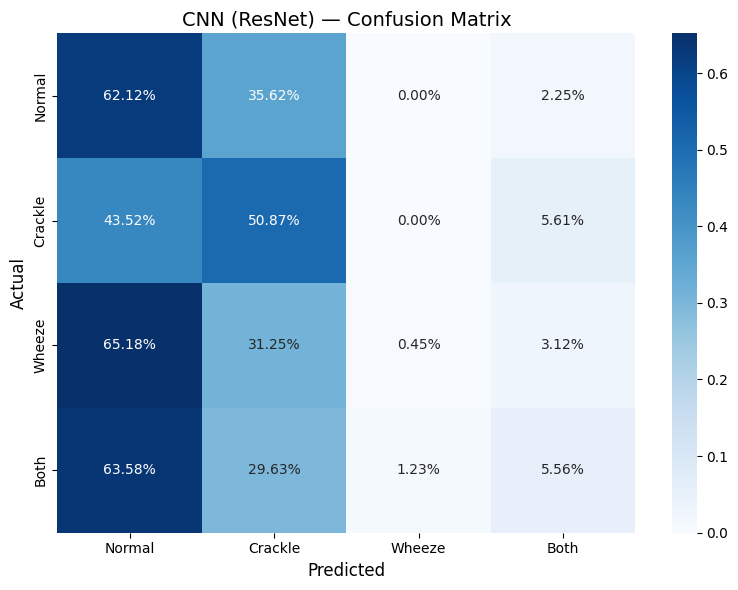

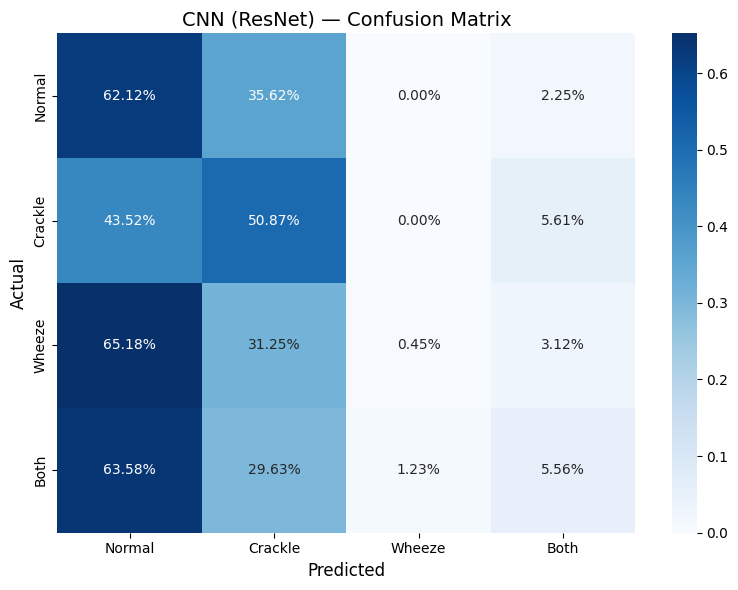

In [5]:
# Load best weights
cnn_model.load_state_dict(torch.load(MODELS_DIR / "cnn_resnet_best.pt", map_location=device))

plot_training_curves(cnn_history, title="CNN (ResNet)", save_path=FIGURES_DIR / "cnn_training_curves.png")

y_true_cnn, y_pred_cnn = predict_cnn(cnn_model, test_loader)
cnn_results = evaluate_predictions(y_true_cnn, y_pred_cnn, title="CNN (ResNet)")

plot_confusion_matrix(
    y_true_cnn, y_pred_cnn, title="CNN (ResNet) — Confusion Matrix",
    save_path=FIGURES_DIR / "cm_cnn_resnet.png"
)

## 3.5 CRNN Model (CNN + Bidirectional GRU)
The CRNN combines the spatial feature extraction of CNNs with the sequential modelling capability of RNNs:

1. **CNN encoder**: Convolutional layers extract local frequency patterns at each time step
2. **Reshape**: The spatial feature maps are reshaped into a sequence — each time frame becomes a feature vector
3. **Bidirectional GRU**: Processes the sequence in both directions, capturing how sound patterns evolve over time
4. **Attention pooling**: Learned attention weights highlight the most diagnostically relevant time steps

This architecture is particularly well-suited for distinguishing:
- **Crackles** — short, explosive bursts (temporally localised)
- **Wheezes** — sustained tonal sounds (temporally extended)
- **Both** — overlapping temporal patterns that require sequential context

In [6]:
class LungSoundCRNN(nn.Module):
    """
    CNN + Bidirectional GRU with attention pooling.
    
    The CNN extracts spatial features from the spectrogram at each time step.
    The BiGRU models temporal dependencies across time steps.
    Attention pooling learns which time steps are most relevant for classification.
    """
    
    def __init__(self, num_classes=4, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        # CNN feature extractor
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),  # Pool frequency only, keep time
            nn.Dropout2d(0.1),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(0.1),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(0.1),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(0.2),
        )
        
        # After CNN: (batch, 256, freq_reduced, time_steps)
        # We'll flatten freq dimension and treat time as sequence
        # 128 mel bins / (2^4 pools) = 8 frequency bins remaining
        self.cnn_output_freq = 8
        rnn_input_size = 256 * self.cnn_output_freq  # 2048
        
        # Bidirectional GRU
        self.rnn = nn.GRU(
            input_size=rnn_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    
    def forward(self, x):
        # x: (batch, 1, 128, time_steps)
        batch_size = x.size(0)
        
        # CNN feature extraction
        cnn_out = self.cnn(x)  # (batch, 256, 8, T')
        
        # Reshape: merge frequency into features, keep time as sequence
        _, channels, freq, time_steps = cnn_out.shape
        cnn_out = cnn_out.permute(0, 3, 1, 2)  # (batch, T', 256, 8)
        cnn_out = cnn_out.reshape(batch_size, time_steps, channels * freq)  # (batch, T', 2048)
        
        # Bidirectional GRU
        rnn_out, _ = self.rnn(cnn_out)  # (batch, T', hidden*2)
        
        # Attention pooling
        attn_weights = self.attention(rnn_out)  # (batch, T', 1)
        attn_weights = torch.softmax(attn_weights, dim=1)  # normalise over time
        context = torch.sum(rnn_out * attn_weights, dim=1)  # (batch, hidden*2)
        
        # Classification
        output = self.classifier(context)  # (batch, num_classes)
        return output


# Instantiate and check
crnn_model = LungSoundCRNN(num_classes=4)
print(f"CRNN parameters: {sum(p.numel() for p in crnn_model.parameters()):,}")

# Quick shape test
with torch.no_grad():
    dummy = torch.randn(2, 1, X_train.shape[1], X_train.shape[2])
    out = crnn_model(dummy)
    print(f"Input shape:  {dummy.shape}")
    print(f"Output shape: {out.shape}")

CRNN parameters: 2,585,381
Input shape:  torch.Size([2, 1, 128, 216])
Output shape: torch.Size([2, 4])


## 3.6 Train CRNN
Training with the same class-weighted loss and early stopping strategy as the CNN. The BiGRU adds temporal modelling capability, which should improve discrimination between crackles (short bursts) and wheezes (sustained tones).

In [7]:
crnn_history = train_cnn(
    model=crnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    class_weights=class_weights,
    model_name="crnn_bigru",
)

Training on: cuda
Epoch [  1/50] Train Loss: 1.3989  Acc: 0.2856  |  Val Loss: 1.3689  Acc: 0.3651
Epoch [  2/50] Train Loss: 1.3900  Acc: 0.3192  |  Val Loss: 1.3795  Acc: 0.3651
Epoch [  3/50] Train Loss: 1.3859  Acc: 0.2612  |  Val Loss: 1.3673  Acc: 0.3651
Epoch [  4/50] Train Loss: 1.3836  Acc: 0.2581  |  Val Loss: 1.4064  Acc: 0.2136
Epoch [  5/50] Train Loss: 1.3789  Acc: 0.3413  |  Val Loss: 1.3535  Acc: 0.3651
Epoch [  6/50] Train Loss: 1.3782  Acc: 0.2898  |  Val Loss: 1.4008  Acc: 0.3405
Epoch [  7/50] Train Loss: 1.3758  Acc: 0.3486  |  Val Loss: 1.4057  Acc: 0.2965
Epoch [  8/50] Train Loss: 1.3659  Acc: 0.3602  |  Val Loss: 1.4872  Acc: 0.3420
Epoch [  9/50] Train Loss: 1.3586  Acc: 0.4426  |  Val Loss: 1.5863  Acc: 0.2756
Epoch [ 10/50] Train Loss: 1.3781  Acc: 0.3221  |  Val Loss: 1.3873  Acc: 0.3810
Epoch [ 11/50] Train Loss: 1.3639  Acc: 0.3589  |  Val Loss: 1.4429  Acc: 0.3579
Epoch [ 12/50] Train Loss: 1.3526  Acc: 0.3647  |  Val Loss: 1.3869  Acc: 0.2179

Early sto

## 3.7 CRNN Evaluation

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\crnn_training_curves.png


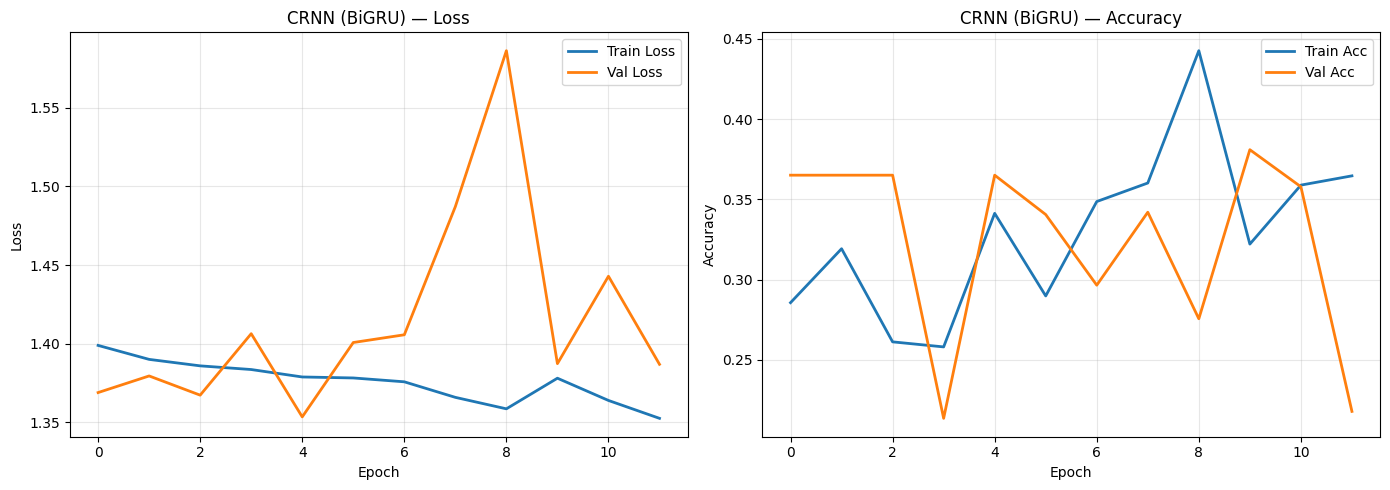


  CRNN (BiGRU)
  Accuracy:          0.4058
  F1 (macro):        0.2527
  F1 (weighted):     0.3750

              precision    recall  f1-score   support

      Normal       0.54      0.44      0.49       800
     Crackle       0.35      0.63      0.45       517
      Wheeze       0.11      0.06      0.08       224
        Both       0.00      0.00      0.00       162

    accuracy                           0.41      1703
   macro avg       0.25      0.28      0.25      1703
weighted avg       0.38      0.41      0.37      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_crnn_bigru.png


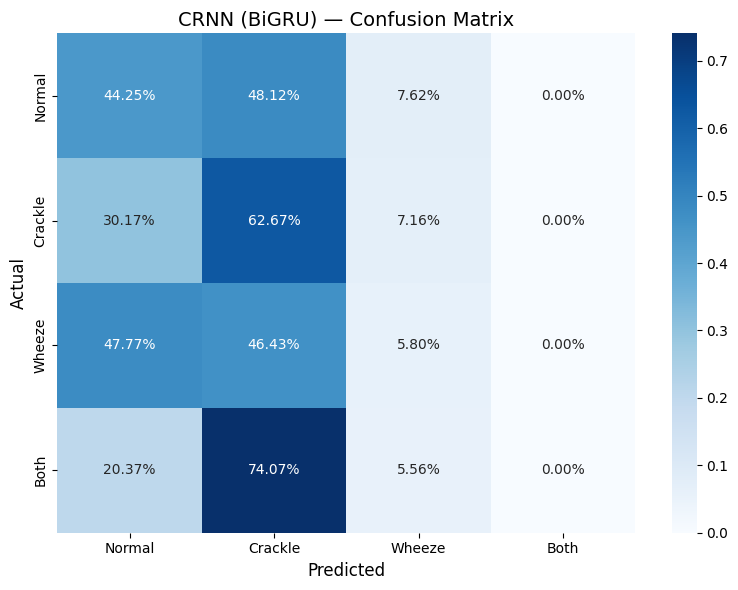

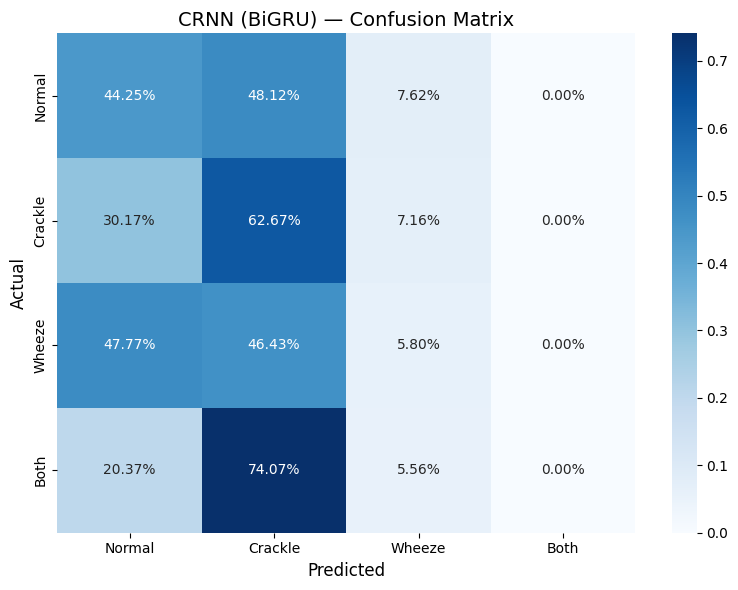

In [8]:
crnn_model.load_state_dict(torch.load(MODELS_DIR / "crnn_bigru_best.pt", map_location=device))

plot_training_curves(crnn_history, title="CRNN (BiGRU)", save_path=FIGURES_DIR / "crnn_training_curves.png")

y_true_crnn, y_pred_crnn = predict_cnn(crnn_model, test_loader)
crnn_results = evaluate_predictions(y_true_crnn, y_pred_crnn, title="CRNN (BiGRU)")

plot_confusion_matrix(
    y_true_crnn, y_pred_crnn, title="CRNN (BiGRU) — Confusion Matrix",
    save_path=FIGURES_DIR / "cm_crnn_bigru.png"
)

## 3.8 Full Model Comparison (ML + DL)
Comparing all six models: four ML baselines and two deep learning architectures.

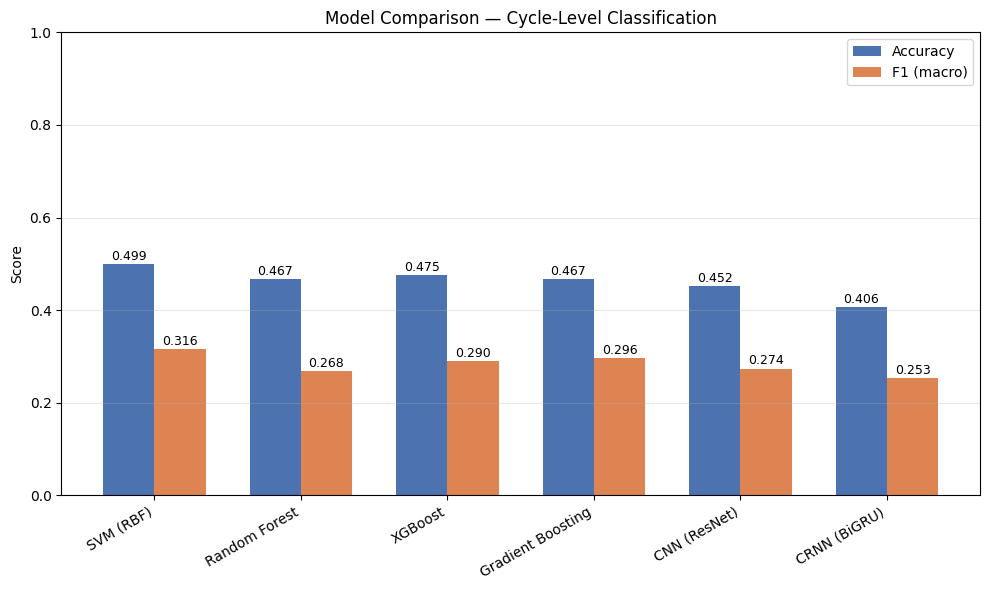


  FINAL RESULTS SUMMARY
Model                    Accuracy   F1 (macro)
----------------------------------------------
SVM (RBF)                  0.4990       0.3160
Random Forest              0.4670       0.2680
XGBoost                    0.4750       0.2900
Gradient Boosting          0.4670       0.2960
CNN (ResNet)               0.4521       0.2737
CRNN (BiGRU)               0.4058       0.2527


In [9]:
# Load ML results
import joblib
from src.models import get_ml_models

# Reload ML results by re-predicting (quick on saved models)
hc_data = np.load(DATA_DIR / 'handcrafted_features.npz')
scaler = joblib.load(MODELS_DIR / 'scaler.joblib')
best_ml = joblib.load(MODELS_DIR / 'best_ml_model.joblib')
X_test_scaled = scaler.transform(hc_data['X_test'])

# Combine all results
all_results = {
    "SVM (RBF)": {"accuracy": 0.499, "f1_macro": 0.316},
    "Random Forest": {"accuracy": 0.467, "f1_macro": 0.268},
    "XGBoost": {"accuracy": 0.475, "f1_macro": 0.290},
    "Gradient Boosting": {"accuracy": 0.467, "f1_macro": 0.296},
    "CNN (ResNet)": cnn_results,
    "CRNN (BiGRU)": crnn_results,
}

compare_models(all_results, save_path=FIGURES_DIR / "all_model_comparison.png")

# Summary table
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 46)
for name, res in all_results.items():
    print(f"{name:<22} {res['accuracy']:>10.4f} {res['f1_macro']:>12.4f}")